In [34]:
# Clasificación con el conjunto de datos `breast_cancer.csv`

## Objetivo

#El objetivo de este ejercicio es desarrollar un modelo de clasificación capaz de determinar la categoría de diagnóstico de una muestra de cáncer de mama a partir de sus características numéricas.

#Durante el desarrollo se realizará:

#1. Exploración y preparación de los datos.
#2. Selección de variables predictoras y variable objetivo.
#3. División de los datos en entrenamiento y prueba.
#4. Construcción de un modelo de Regresión Logística.
#5. Evaluación mediante métricas de clasificación.
#6. Optimización mediante búsqueda de hiperparámetros.
#7. Comparación entre el modelo base y el modelo optimizado.
#8. Visualización de los resultados.
#9. Guardado del modelo final.

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [40]:
ruta = "/Users/x/OneDrive/Escritorio/universidad/9no/fili/analisis-supervisado-no-supervisado/datasets/breast-cancer.csv"

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 569
Columnas: 32


In [41]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [43]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [44]:
print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [45]:
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [46]:
# Eliminar la columna identificadora
df = df.drop(columns=["id"])

print("Columnas después de eliminar el identificador:")
print(df.columns.tolist())

Columnas después de eliminar el identificador:
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [47]:
print("Valores de la variable diagnosis:")
print(df["diagnosis"].value_counts())

Valores de la variable diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [48]:
print("Proporción de cada clase:")
print(df["diagnosis"].value_counts(normalize=True))

Proporción de cada clase:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [49]:
# Convertir diagnosis a valores numéricos
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Valores codificados de diagnosis:")
print(df["diagnosis"].value_counts())

print("\nValores únicos:")
print(df["diagnosis"].unique())

Valores codificados de diagnosis:
diagnosis
0    357
1    212
Name: count, dtype: int64

Valores únicos:
[1 0]


In [50]:
# Variables predictoras
X = df.drop(columns=["diagnosis"])

# Variable objetivo
y = df["diagnosis"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nPrimeras columnas de X:")
print(X.columns.tolist())

print("\nPrimeros valores de y:")
print(y.head())

Forma de X: (569, 30)
Forma de y: (569,)

Primeras columnas de X:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Primeros valores de y:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución de clases en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: 455
Datos de prueba: 114

Distribución de clases en entrenamiento:
diagnosis
0    285
1    170
Name: count, dtype: int64

Distribución de clases en prueba:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [52]:
# Pipeline: estandarización + regresión logística
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

print("Pipeline creado correctamente.")

Pipeline creado correctamente.


In [53]:
# Entrenamiento del modelo base
pipeline.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [54]:
# Predicciones sobre el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Probabilidades de pertenecer a la clase positiva
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [55]:
# Cálculo de métricas del modelo base
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Resultados del modelo base:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

Resultados del modelo base:
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1-score:  0.9512
AUC-ROC:   0.9960


In [56]:
print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benigno", "Maligno"]
))

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



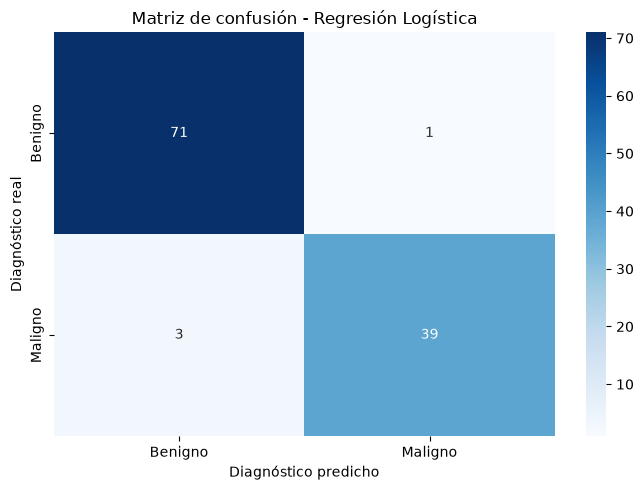

In [57]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Diagnóstico predicho")
plt.ylabel("Diagnóstico real")
plt.tight_layout()

plt.savefig(
    "../figuras/breast_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

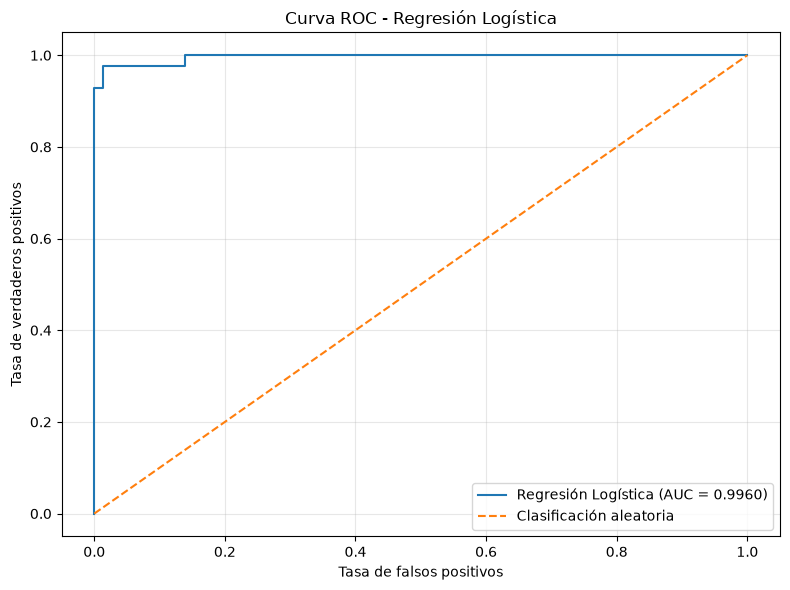

In [58]:
# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Regresión Logística (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title("Curva ROC - Regresión Logística")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/breast_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
pipeline.named_steps["logistic"].coef_

array([[ 0.36115007,  0.4822194 ,  0.35315987,  0.43995028,  0.35062156,
        -0.43954615,  0.78229835,  0.95281283, -0.16399087, -0.08086512,
         1.23332517, -0.40761126,  0.74829471,  0.90902906,  0.24799098,
        -0.9069248 , -0.09234069,  0.48208908, -0.33065773, -0.59387632,
         0.89696783,  1.43409317,  0.72311148,  0.90047661,  0.42020675,
        -0.17348751,  0.9114058 ,  0.70399881,  1.06126366,  0.05486988]])

In [60]:
# Obtener coeficientes del modelo
coeficientes = pipeline.named_steps["logistic"].coef_[0]

coef_df = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": coeficientes
})

# Ordenar por magnitud absoluta
coef_df["magnitud"] = coef_df["coeficiente"].abs()

coef_df = coef_df.sort_values(
    "magnitud",
    ascending=False
)

coef_df.head(10)

,variable,coeficiente,magnitud
21,texture_worst,1.434093,1.434093
10,radius_se,1.233325,1.233325
28,symmetry_worst,1.061264,1.061264
7,concave points_mean,0.952813,0.952813
26,concavity_worst,0.911406,0.911406
13,area_se,0.909029,0.909029
15,compactness_se,-0.906925,0.906925
23,area_worst,0.900477,0.900477
20,radius_worst,0.896968,0.896968
6,concavity_mean,0.782298,0.782298


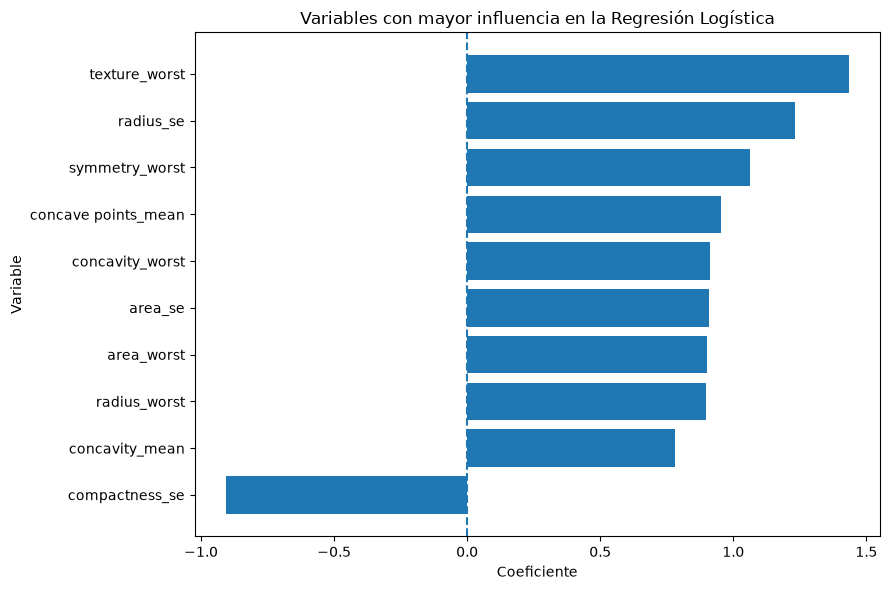

In [61]:
# Seleccionar los 10 coeficientes más relevantes
top_coef = coef_df.head(10).sort_values("coeficiente")

plt.figure(figsize=(9, 6))

plt.barh(
    top_coef["variable"],
    top_coef["coeficiente"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Variables con mayor influencia en la Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    "../figuras/breast_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
param_grid = {
    "logistic__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [63]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor F1-score promedio:")
print(f"{grid_search.best_score_:.4f}")

Mejores hiperparámetros:
{'logistic__C': 10}

Mejor F1-score promedio:
0.9611


In [64]:
# Obtener el mejor modelo encontrado por GridSearchCV
best_model = grid_search.best_estimator_

print("Mejor modelo:")
print(best_model)

Mejor modelo:
Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(C=10, max_iter=5000))])


In [65]:
# Predicciones del modelo optimizado
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Métricas del modelo optimizado
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_prob_best)

print("Resultados del modelo optimizado:")
print(f"Accuracy:  {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")
print(f"AUC-ROC:   {auc_best:.4f}")

Resultados del modelo optimizado:
Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1-score:  0.9639
AUC-ROC:   0.9864


In [66]:
print("Reporte de clasificación del modelo optimizado:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Benigno", "Maligno"]
))

Reporte de clasificación del modelo optimizado:
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [67]:
cm_base = confusion_matrix(y_test, y_pred)

print("Matriz de confusión - Modelo base:")
print(cm_base)

Matriz de confusión - Modelo base:
[[71  1]
 [ 3 39]]


In [68]:
cm_best = confusion_matrix(y_test, y_pred_best)

print("Matriz de confusión - Modelo optimizado:")
print(cm_best)

Matriz de confusión - Modelo optimizado:
[[71  1]
 [ 2 40]]


In [69]:
# Comparación de modelos
comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC-ROC"
    ],
    "Modelo base": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],
    "Modelo optimizado": [
        accuracy_best,
        precision_best,
        recall_best,
        f1_best,
        auc_best
    ]
})

comparacion["Diferencia"] = (
    comparacion["Modelo optimizado"] -
    comparacion["Modelo base"]
)

comparacion

,Métrica,Modelo base,Modelo optimizado,Diferencia
0,Accuracy,0.964912,0.973684,0.008772
1,Precision,0.975000,0.975610,0.000610
2,Recall,0.928571,0.952381,0.023810
3,F1-score,0.951220,0.963855,0.012636
4,AUC-ROC,0.996032,0.986442,-0.009590


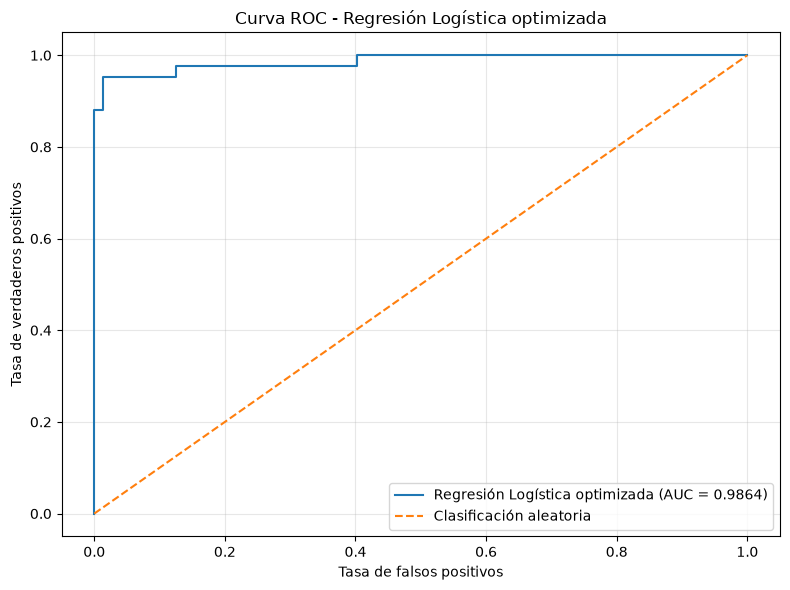

In [70]:
# Curva ROC del modelo optimizado
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_best,
    tpr_best,
    label=f"Regresión Logística optimizada (AUC = {auc_best:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title("Curva ROC - Regresión Logística optimizada")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/breast_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

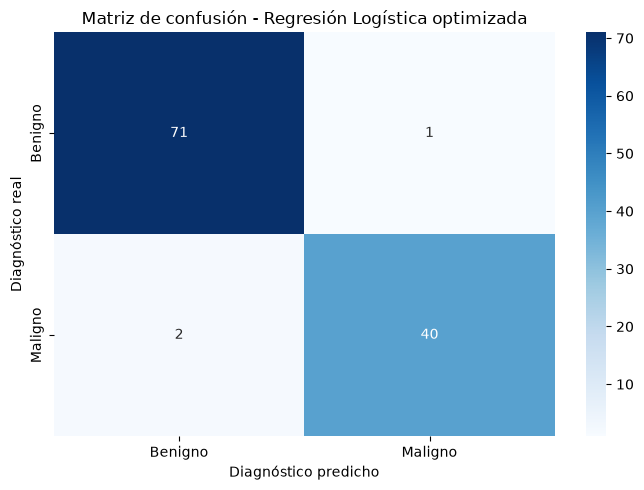

In [71]:
# Matriz de confusión del modelo optimizado
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.title("Matriz de confusión - Regresión Logística optimizada")
plt.xlabel("Diagnóstico predicho")
plt.ylabel("Diagnóstico real")
plt.tight_layout()

plt.savefig(
    "../figuras/breast_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
import joblib
import os

# Crear directorio si no existe
os.makedirs("../models/classification", exist_ok=True)

# Guardar modelo final
model_path = "../models/classification/breast_cancer_logistic_regression.joblib"

joblib.dump(best_model, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ../models/classification/breast_cancer_logistic_regression.joblib


In [73]:
# Comprobar que el modelo puede cargarse nuevamente
loaded_model = joblib.load(model_path)

print("Modelo cargado correctamente.")
print(loaded_model)

Modelo cargado correctamente.
Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(C=10, max_iter=5000))])
